# dtfit - Quickstart

**dtfit** fits models that are *nonlinear in their parameters* - exponential,
transcendental, oscillatory, mixed - for nonlinear smoothing and forecasting,
built in the scheme of differential / non-Taylor transformations (from the
author's PhD work).

You bring a model as a small **sympy expression string** (e.g. `"a*exp(b*t)"`)
and your data; dtfit recovers the parameters. The public API spans batch
fitters, a self-seeding model catalog, a scikit-learn estimator, streaming
trackers, and scale-out helpers.

```
pip install dtfit            # core
pip install "dtfit[viz]"     # + matplotlib for the plots in these guides
```

This notebook gets you to a first fit in a minute. The rest of the series:

| # | Guide |
|---|-------|
| 02 | Fitting methods - LSI / EDA / DSB |
| 03 | Model catalog, `suggest_models`, `auto_estimate` / `auto_forecast` |
| 04 | scikit-learn `NonlineRegressor` |
| 05 | Streaming / online trackers |
| 06 | Scaling - parallel, batched, partitioned |
| 07 | Diagnostics, visualization & serialization |

In [1]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt

# Fitting at extreme parameter trials can overflow exp() harmlessly; keep the
# guide output clean.
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)

## Your first fit - `fit_lsi`

Pick a model expression (sympy syntax) and the variable name. Everything in the
expression except the variable is a free parameter. Here: `a` and `b`.

In [2]:
from dtfit import fit_lsi

x = np.linspace(0, 3, 200)
y = 1.4 * np.exp(0.8 * x) + rng.normal(0, 0.15, x.size)

res = fit_lsi(x, y, "a*exp(b*t)", "t")
print(res.summary())

FittingResult: a*exp(b*t)
  a = 1.40784 +/- 0.0066
  b = 0.797447 +/- 0.0019


The fit comes back as a **`FittingResult`** - self-describing (model expression,
parameter names, coefficients, covariance) and ready to predict.

params: {'a': 1.4078373342399602, 'b': 0.7974468457028752}
coeffs: [1.40783733 0.79744685]


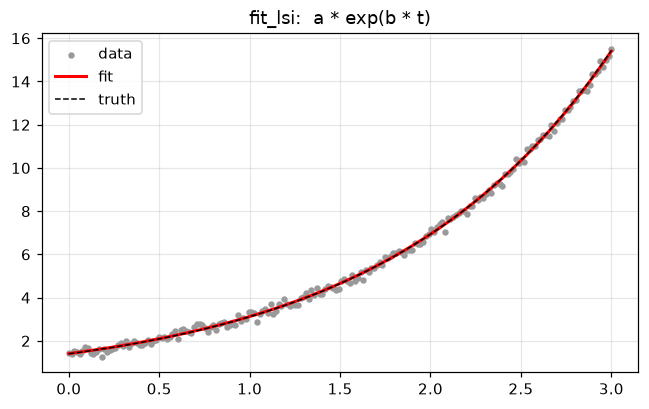

In [3]:
print("params:", res.params)        # {name: value}
print("coeffs:", res.coeffs)        # ordered by parameter name

xs = np.linspace(x.min(), x.max(), 400)
plt.scatter(x, y, s=10, color="0.6", label="data")
plt.plot(xs, res.predict(xs), "r-", lw=2, label="fit")
plt.plot(xs, 1.4 * np.exp(0.8 * xs), "k--", lw=1, label="truth")
plt.legend(); plt.title("fit_lsi:  a * exp(b * t)"); plt.show()

## Uncertainty

When the system is overdetermined the result carries a parameter **covariance**,
so you get standard errors, confidence intervals, and prediction bands
(propagated by the delta method).

std errors : {'a': 0.006601773754396104, 'b': 0.001903580284615307}
95% CI     : {'a': (1.394898095447262, 1.4207765730326583), 'b': (0.7937158969033486, 0.8011777945024017)}


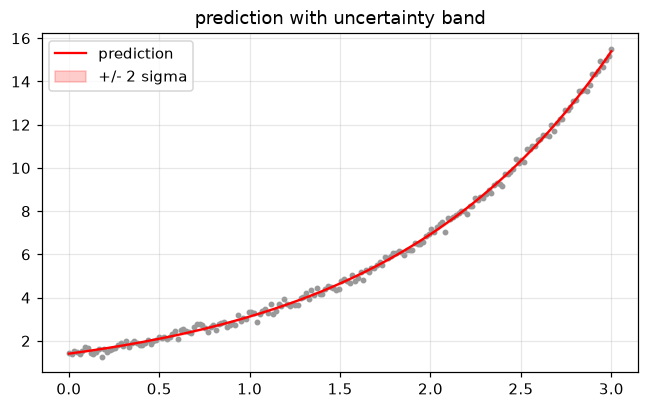

In [4]:
print("std errors :", res.stderr())
print("95% CI     :", res.confidence_intervals())

y_hat, y_sd = res.predict(xs, return_std=True)
plt.scatter(x, y, s=8, color="0.6")
plt.plot(xs, y_hat, "r-", label="prediction")
plt.fill_between(xs, y_hat - 2 * y_sd, y_hat + 2 * y_sd,
                 color="r", alpha=0.2, label="+/- 2 sigma")
plt.legend(); plt.title("prediction with uncertainty band"); plt.show()

## Don't want to choose the estimator? Let dtfit route it

`auto_estimate` picks the estimator variant from the signal's *shape*; the model
catalog and `suggest_models` can even rank candidate families for you
(notebook 03).

In [5]:
from dtfit import auto_estimate

res2 = auto_estimate(x, y, "a*exp(b*t)", "t")
print(res2.summary())

FittingResult: a*exp(b*t)
  a = 1.40784 +/- 0.0066
  b = 0.797447 +/- 0.0019
